
# Regressão Linear e Regressão Múltipla (com métricas MAE, MSE, RMSE e R²)

**Objetivo:** treinar modelos de regressão (simples e múltipla), calcular métricas de avaliação e visualizar os resultados em gráficos claros.  
No final há um **exercício** para você aplicar os mesmos passos em outro conjunto de dados.

> Requisitos: `numpy`, `pandas`, `matplotlib`, `scikit-learn` (todas disponíveis no Google Colab).


In [ ]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Funções auxiliares
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

def print_metrics(metrics, title=None):
    if title:
        print(f"\n=== {title} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")


## Parte 1 — Regressão Linear (1 variável)

Vamos criar um conjunto de dados sintético onde `y ≈ 3x + 5 + ruído`.


In [ ]:
# Gerar dados sintéticos (regressão linear simples)
rng = np.random.default_rng(42)
n = 200
X = rng.uniform(low=0, high=10, size=n)
noise = rng.normal(loc=0, scale=2, size=n)
y = 3*X + 5 + noise

# Transformar X para formato (n_samples, 1) exigido pelo scikit-learn
X = X.reshape(-1, 1)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train[:5], y_train[:5]

(array([[1.76772783],
        [9.3604357 ],
        [9.75622352],
        [3.29861212],
        [7.19462956]]),
 array([12.65800727, 34.77007748, 37.08363427, 17.23833056, 27.461875  ]))

In [ ]:
# Treinar a regressão linear
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Prever
y_pred_train = linreg.predict(X_train)
y_pred_test  = linreg.predict(X_test)

# Métricas
metrics_train = compute_metrics(y_train, y_pred_train)
metrics_test  = compute_metrics(y_test,  y_pred_test)

print_metrics(metrics_train, title="Métricas - Treino (Linear Simples)")
print_metrics(metrics_test,  title="Métricas - Teste  (Linear Simples)")

print(f"\nCoeficiente (inclinação): {linreg.coef_[0]:.4f}")
print(f"Intercepto: {linreg.intercept_:.4f}")


=== Métricas - Treino (Linear Simples) ===
MAE: 1.6264
MSE: 4.1199
RMSE: 2.0297
R2: 0.9518

=== Métricas - Teste  (Linear Simples) ===
MAE: 1.5233
MSE: 3.7227
RMSE: 1.9294
R2: 0.9468

Coeficiente (inclinação): 3.1375
Intercepto: 4.1614


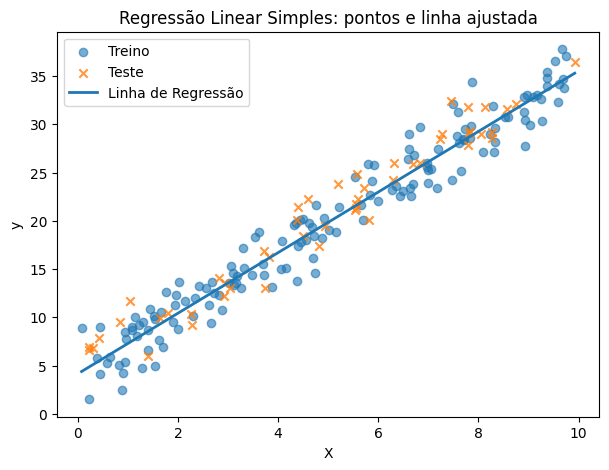

In [ ]:
# Gráfico: dados (pontos) + linha de regressão
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Treino")
plt.scatter(X_test, y_test, alpha=0.8, marker="x", label="Teste")

# Linha de regressão: para uma única variável, podemos traçar linha sobre o range
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = linreg.predict(x_line)
plt.plot(x_line, y_line, linewidth=2, label="Linha de Regressão")

plt.title("Regressão Linear Simples: pontos e linha ajustada")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

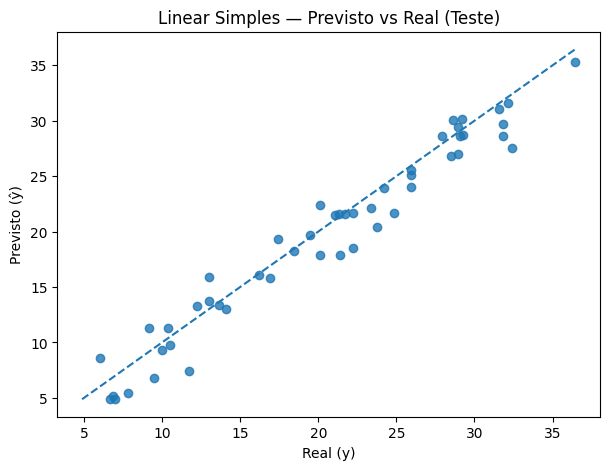

In [ ]:
# Gráfico: Previsto vs Real (Teste) + linha y = x
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_test, alpha=0.8)
min_v = min(np.min(y_test), np.min(y_pred_test))
max_v = max(np.max(y_test), np.max(y_pred_test))
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Linear Simples — Previsto vs Real (Teste)")
plt.xlabel("Real (y)")
plt.ylabel("Previsto (ŷ)")
plt.show()

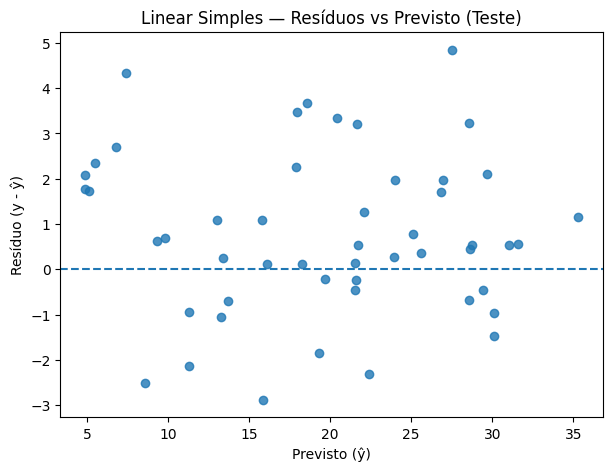

In [ ]:
# Gráfico: Resíduos vs Previsto (Teste)
resid_test = y_test - y_pred_test

plt.figure(figsize=(7,5))
plt.scatter(y_pred_test, resid_test, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.title("Linear Simples — Resíduos vs Previsto (Teste)")
plt.xlabel("Previsto (ŷ)")
plt.ylabel("Resíduo (y - ŷ)")
plt.show()


## Parte 2 — Regressão Múltipla (várias variáveis)

Agora vamos simular um conjunto de dados com **3 variáveis explicativas**.  
A relação será `y ≈ 2x1 - 1.5x2 + 0.8x3 + 10 + ruído`.


In [ ]:
# Dados sintéticos para regressão múltipla
rng = np.random.default_rng(123)
n = 500
X1 = rng.uniform(0, 20, size=n)
X2 = rng.uniform(-10, 10, size=n)
X3 = rng.normal(5, 3, size=n)

noise = rng.normal(0, 3, size=n)
y_multi = 2*X1 - 1.5*X2 + 0.8*X3 + 10 + noise

X_multi = np.column_stack([X1, X2, X3])

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.25, random_state=7)

# Treinar
linreg_m = LinearRegression()
linreg_m.fit(X_train_m, y_train_m)

# Prever
y_pred_train_m = linreg_m.predict(X_train_m)
y_pred_test_m  = linreg_m.predict(X_test_m)

# Métricas
metrics_train_m = compute_metrics(y_train_m, y_pred_train_m)
metrics_test_m  = compute_metrics(y_test_m,  y_pred_test_m)

print_metrics(metrics_train_m, title="Métricas - Treino (Múltipla)")
print_metrics(metrics_test_m,  title="Métricas - Teste  (Múltipla)")

print("\nCoeficientes:", linreg_m.coef_)
print("Intercepto:", linreg_m.intercept_)


=== Métricas - Treino (Múltipla) ===
MAE: 2.4720
MSE: 9.5337
RMSE: 3.0877
R2: 0.9586

=== Métricas - Teste  (Múltipla) ===
MAE: 2.3504
MSE: 9.1532
RMSE: 3.0254
R2: 0.9577

Coeficientes: [ 1.97899837 -1.50995769  0.77669092]
Intercepto: 10.329380854820464


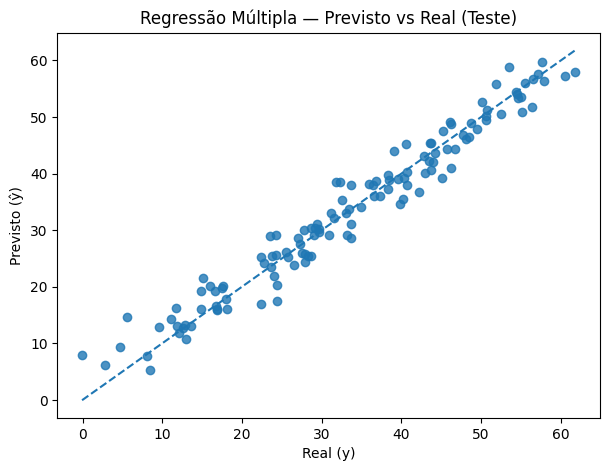

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.8)
min_v = min(np.min(y_test_m), np.min(y_pred_test_m))
max_v = max(np.max(y_test_m), np.max(y_pred_test_m))
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Regressão Múltipla — Previsto vs Real (Teste)")
plt.xlabel("Real (y)")
plt.ylabel("Previsto (ŷ)")
plt.show()

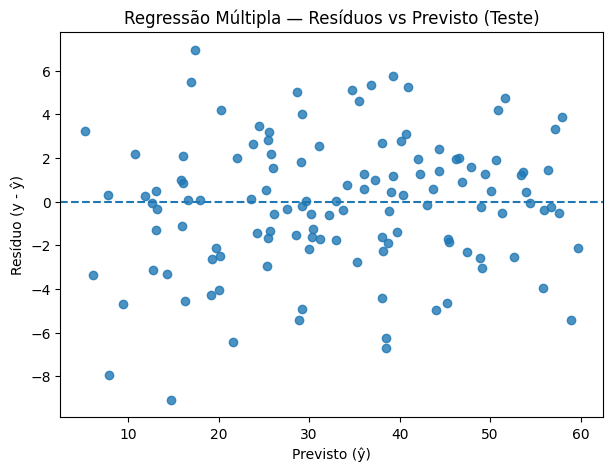

In [ ]:
resid_test_m = y_test_m - y_pred_test_m

plt.figure(figsize=(7,5))
plt.scatter(y_pred_test_m, resid_test_m, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.title("Regressão Múltipla — Resíduos vs Previsto (Teste)")
plt.xlabel("Previsto (ŷ)")
plt.ylabel("Resíduo (y - ŷ)")
plt.show()

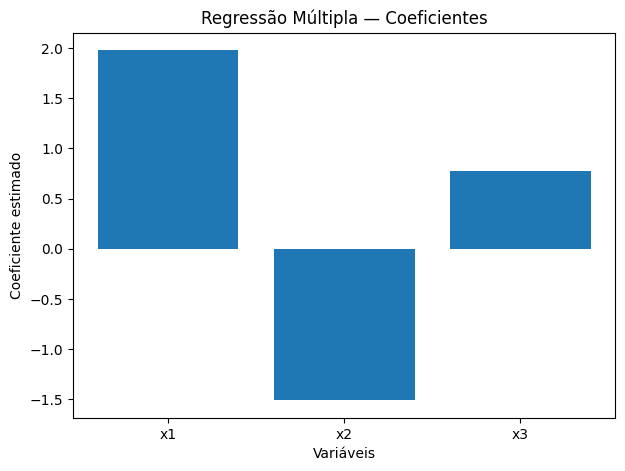

In [ ]:
# Importância (coeficientes) — cuidado: em regressão linear os coeficientes dependem da escala
features = ["x1", "x2", "x3"]
coefs = linreg_m.coef_

plt.figure(figsize=(7,5))
plt.bar(features, coefs)
plt.title("Regressão Múltipla — Coeficientes")
plt.xlabel("Variáveis")
plt.ylabel("Coeficiente estimado")
plt.show()



### Interpretação rápida das métricas
- **MAE**: erro médio absoluto (mesma unidade do alvo).  
- **MSE**: erro quadrático médio (penaliza mais erros grandes).  
- **RMSE**: raiz do MSE (mesma unidade do alvo; mais interpretável).  
- **R²**: proporção de variância explicada (pode ser negativo se o modelo for pior que usar a média).

> Em geral, **menores MAE/MSE/RMSE** e **maior R²** indicam melhor ajuste (avaliar sempre em dados de teste).



## Exercício (para os alunos)

1. Escolha **outro conjunto de dados** (pode ser um CSV seu ou um dataset simples).  
2. Separe a(s) coluna(s) de entrada `X` e a coluna alvo `y`.  
3. Reaproveite as funções `compute_metrics` e os gráficos acima para:
   - treinar uma regressão linear simples (escolha apenas **1 variável** de `X`),  
   - treinar uma regressão múltipla (use **2 ou mais variáveis**),  
   - **comparar as métricas** (MAE, MSE, RMSE, R²) entre os dois modelos,  
   - gerar os **mesmos gráficos** (previsto vs real, resíduos vs previsto), e — para a múltipla — o gráfico de **coeficientes**.

> Dica: se você não tiver um CSV, crie dados sintéticos com `numpy`, como nos exemplos.

Preencha e rode a célula abaixo com seu experimento:


In [ ]:
# === EXERCÍCIO DO ALUNO ===

# 1) Carregue seus dados em um DataFrame (ex.: pd.read_csv('meus_dados.csv'))
# df = pd.read_csv('meus_dados.csv')

# 2) Defina X e y (ajuste os nomes das colunas)
# X = df[['coluna1', 'coluna2', 'coluna3']].values
# y = df['alvo'].values

# 3) Divida em treino/teste
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4) Treine regressão linear (simples): escolha UMA coluna de X, por exemplo a coluna 0
# X_train_1 = X_train[:, [0]]
# X_test_1  = X_test[:, [0]]
# m1 = LinearRegression().fit(X_train_1, y_train)
# y_pred_1 = m1.predict(X_test_1)
# print_metrics(compute_metrics(y_test, y_pred_1), title="Seu experimento — Linear Simples")

# 5) Treine regressão múltipla (todas as colunas de X)
# m2 = LinearRegression().fit(X_train, y_train)
# y_pred_2 = m2.predict(X_test)
# print_metrics(compute_metrics(y_test, y_pred_2), title="Seu experimento — Múltipla")

# 6) Gráficos (modifique rótulos/títulos conforme necessário)
# plt.figure(figsize=(7,5))
# plt.scatter(y_test, y_pred_2, alpha=0.8)
# min_v = min(np.min(y_test), np.min(y_pred_2))
# max_v = max(np.max(y_test), np.max(y_pred_2))
# plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
# plt.title("Seu experimento — Previsto vs Real (Múltipla)")
# plt.xlabel("Real (y)")
# plt.ylabel("Previsto (ŷ)")
# plt.show()

# plt.figure(figsize=(7,5))
# plt.scatter(y_pred_2, y_test - y_pred_2, alpha=0.8)
# plt.axhline(0, linestyle="--")
# plt.title("Seu experimento — Resíduos vs Previsto (Múltipla)")
# plt.xlabel("Previsto (ŷ)")
# plt.ylabel("Resíduo (y - ŷ)")
# plt.show()

# if hasattr(m2, "coef_"):
#     plt.figure(figsize=(7,5))
#     plt.bar([f"x{i+1}" for i in range(X.shape[1])], m2.coef_)
#     plt.title("Seu experimento — Coeficientes (Múltipla)")
#     plt.xlabel("Variáveis")
#     plt.ylabel("Coeficiente")
#     plt.show()